<a href="https://colab.research.google.com/github/SaiPranathi16/envision-ai-interior-redesign/blob/main/Envision_Week3_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Envision — Week 3: Style Generation (Stable Diffusion + ControlNet)

**Before running:** `Runtime > Change runtime type` → T4 GPU.

This is the core module of your project. It:
1. Loads your saved structure map from Week 1 (Canny edges)
2. Loads pretrained Stable Diffusion + ControlNet
3. Generates a redesigned room image conditioned on that structure map plus a style prompt

**Expect to run the generation cell several times with different prompts/settings** — getting a convincing result takes iteration. That's normal and expected, not a sign something is broken.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/Envision_Project'
sample_filename = 'Room.jpg'  # change this to whichever photo you want to redesign
sample_path = f'{PROJECT_DIR}/sample_images/{sample_filename}'

import os
assert os.path.exists(sample_path), 'File not found — check the filename matches exactly.'
print('Using:', sample_path)

Mounted at /content/drive
Using: /content/drive/MyDrive/Envision_Project/sample_images/Room.jpg


## Install libraries
(If you already ran this in a previous session in this runtime, it'll just confirm they're installed.)

In [2]:
!pip install -q diffusers transformers accelerate opencv-python-headless controlnet-aux xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.6 MB/s eta 0:00:00


## (Optional) Hugging Face login
Not required to run this notebook, but recommended if you hit rate-limit warnings. Skip this cell if you don't have a token set up yet.

In [3]:
# Uncomment and run if you've set up an HF_TOKEN secret (see the key icon in the left sidebar)
# from google.colab import userdata
# from huggingface_hub import login
# login(userdata.get('HF_TOKEN'))

## 1. Generate the structure map (Canny) from your room photo
This is the conditioning input that keeps your room's real layout intact during generation.

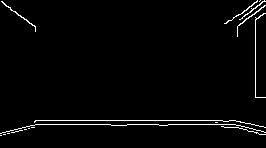

In [4]:
import cv2
import numpy as np
from PIL import Image

image = Image.open(sample_path).convert('RGB')
image_np = np.array(image)

low_threshold = 100
high_threshold = 200
edges = cv2.Canny(image_np, low_threshold, high_threshold)
edges = edges[:, :, None]
edges = np.concatenate([edges, edges, edges], axis=2)
control_image = Image.fromarray(edges)

control_image.save(f'{PROJECT_DIR}/outputs/control_map.png')
control_image

## 2. Load ControlNet + Stable Diffusion
First run downloads several GB of model weights — this can take a few minutes. It's cached after that, so re-running later in the same session is fast.

In [6]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

controlnet = ControlNetModel.from_pretrained(
    'lllyasviel/sd-controlnet-canny', torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None
)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)
pipe.enable_model_cpu_offload()

print('Pipeline loaded.')

Using device: cuda


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline loaded.


## 3. Build your prompt and generate

This is where your Module 1 preferences (room type, tone, curtain style) plug in — they just become part of this text prompt. Edit the variables below and re-run this cell as many times as you want to try different styles.

**conditioning_scale** controls how strictly the output follows your room's structure vs. how much creative freedom the model has:
- Higher (0.8–1.0) = sticks closely to your room's real layout, less dramatic style change
- Lower (0.4–0.6) = more stylistic freedom, but risks drifting from the real layout

Start around 0.7 and adjust based on what you see.

Prompt: a modern minimalist living room interior, warm earthy tones, linen curtains, high quality, photorealistic, interior design magazine photo, well lit


  0%|          | 0/25 [00:00<?, ?it/s]

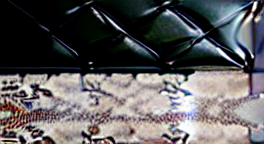

In [7]:
room_type = 'living room'
tone = 'warm earthy tones'
style = 'modern minimalist'
curtain_style = 'linen curtains'

prompt = (
    f'a {style} {room_type} interior, {tone}, {curtain_style}, '
    f'high quality, photorealistic, interior design magazine photo, well lit'
)
negative_prompt = 'blurry, low quality, distorted, extra walls, warped structure, cartoon'

print('Prompt:', prompt)

generator = torch.manual_seed(42)

output = pipe(
    prompt,
    negative_prompt=negative_prompt,
    image=control_image,
    num_inference_steps=25,
    controlnet_conditioning_scale=0.7,
    generator=generator
)

generated_image = output.images[0]
generated_image

## 4. View before/after side by side and save

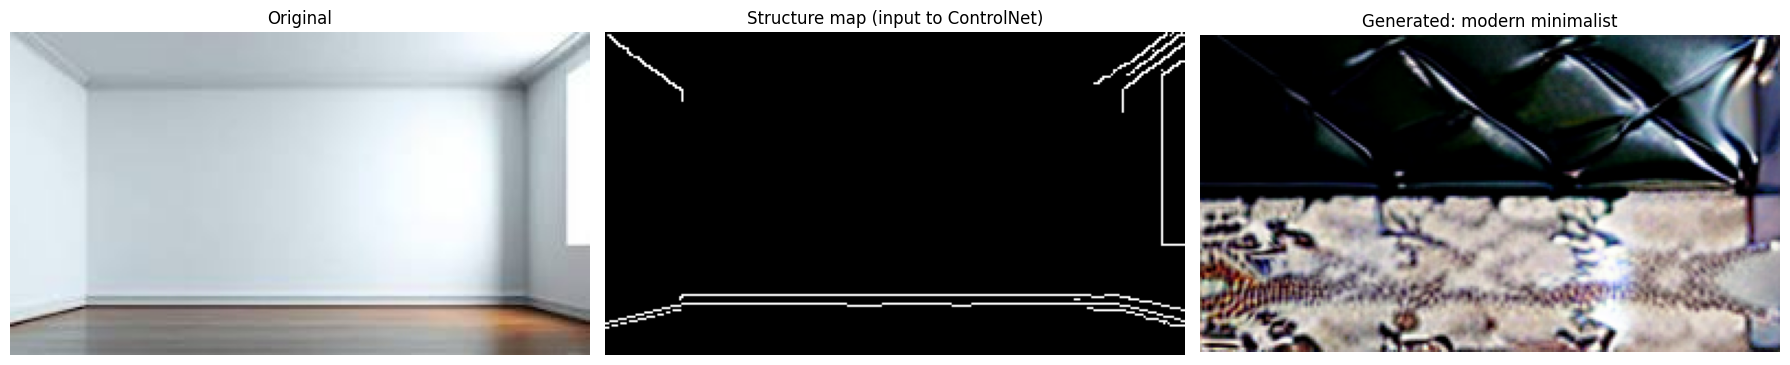

Saved: redesign_modern_minimalist_1786068106.png


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(image); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(control_image); ax[1].set_title('Structure map (input to ControlNet)'); ax[1].axis('off')
ax[2].imshow(generated_image); ax[2].set_title(f'Generated: {style}'); ax[2].axis('off')
plt.tight_layout()
plt.show()

import time
save_name = f'redesign_{style.replace(" ", "_")}_{int(time.time())}.png'
generated_image.save(f'{PROJECT_DIR}/outputs/{save_name}')
print('Saved:', save_name)

## What to do if the result doesn't look right
- **Room looks warped / structure not preserved** → increase `controlnet_conditioning_scale` (try 0.8–0.9)
- **Style barely changed from original** → decrease `controlnet_conditioning_scale` (try 0.5–0.6), or make your prompt more descriptive
- **Weird artifacts / blurry areas** → try a different `generator` seed (change the number in `torch.manual_seed(42)`), or increase `num_inference_steps` to 30–35 (slower, but higher quality)
- **Session runs out of GPU memory** → `Runtime > Restart session`, then re-run from the model loading cell (skip the earlier setup cells if variables are still fine — but restarting clears everything, so you'll need to re-run from the top)

## What's next (Week 4)
- Wrap this into a function that generates multiple style variations at once
- Start building the Streamlit interface so this runs as an actual web app instead of a notebook

**Try this now:** run the generation cell 2-3 times with different `style` and `tone` values and see how the output changes. This hands-on experimentation is exactly how you'll tune your final prompt logic.